In [1]:
import pandas as pd 
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

In [2]:
oews_full = pd.read_csv("../data/processed/oews_all_occupations_2015_2025.csv")
oews_2025 = oews_full[oews_full["year"] == 2025][["soc_code","occupation_title","employment","median_wage"]]

full_skill_wage = pd.read_csv("../data/processed/full_skill_wage_analysis.csv")

In [3]:
skill_pivot = full_skill_wage.pivot_table(
    index="soc_code",
    columns="skill_name",
    values="importance_score",
    aggfunc="first"
).reset_index()

print(skill_pivot.shape)
skill_pivot.head()

(759, 11)


skill_name,soc_code,Active Learning,Active Listening,Critical Thinking,Learning Strategies,Mathematics,Monitoring,Reading Comprehension,Science,Speaking,Writing
0,11-1011,3.75,4.00,4.38,3.12,3.25,4.00,4.12,1.62,4.25,4.12
1,11-1021,3.62,4.00,3.88,3.00,2.62,4.00,4.00,1.50,4.00,3.50
2,11-2011,3.38,4.12,3.88,3.00,2.88,3.50,3.75,1.50,4.12,3.75
3,11-2021,3.88,4.12,3.88,3.25,3.00,3.88,3.88,1.75,4.00,3.25
4,11-2022,3.75,4.00,3.88,3.12,3.00,3.88,3.88,1.62,4.00,3.62


In [4]:
features = skill_pivot.merge(oews_2025, on="soc_code", how="inner")
features = features.dropna()

print(features.shape)
features.head()

(755, 14)


,soc_code,Active Learning,Active Listening,Critical Thinking,Learning Strategies,Mathematics,Monitoring,Reading Comprehension,Science,Speaking,Writing,occupation_title,employment,median_wage
0,11-1011,3.75,4.00,4.38,3.12,3.25,4.00,4.12,1.62,4.25,4.12,Chief Executives,204350.0,213990.0
1,11-1021,3.62,4.00,3.88,3.00,2.62,4.00,4.00,1.50,4.00,3.50,General and Operations Managers,3503020.0,105770.0
2,11-2011,3.38,4.12,3.88,3.00,2.88,3.50,3.75,1.50,4.12,3.75,Advertising and Promotions Managers,21470.0,133660.0
3,11-2021,3.88,4.12,3.88,3.25,3.00,3.88,3.88,1.75,4.00,3.25,Marketing Managers,395240.0,166790.0
4,11-2022,3.75,4.00,3.88,3.12,3.00,3.88,3.88,1.62,4.00,3.62,Sales Managers,637080.0,148270.0


In [5]:


feature_columns = ["Active Learning", "Active Listening", "Critical Thinking", "Learning Strategies",
                    "Mathematics", "Monitoring", "Reading Comprehension", "Science", "Speaking", "Writing",
                    "employment", "median_wage"]

X = features[feature_columns]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[ 1.20290832  0.90853792  1.91864804  0.60884094  1.2836559   1.80001621
   1.19411549 -0.28087458  1.45320294  1.50137447  0.03440888  3.02911473]
 [ 0.96935584  0.90853792  0.86227788  0.40996944  0.20079534  1.80001621
   0.98521618 -0.41810824  0.96582389  0.558989    7.55834097  0.68130193]
 [ 0.53818202  1.15663466  0.86227788  0.40996944  0.64769017  0.54232368
   0.55000928 -0.41810824  1.19976584  0.93898314 -0.38272187  1.2863703 ]
 [ 1.43646081  1.15663466  0.86227788  0.82428507  0.85394933  1.49817001
   0.77631687 -0.13220479  0.96582389  0.17899486  0.46980963  2.0051195 ]
 [ 1.20290832  0.90853792  0.86227788  0.60884094  0.85394933  1.49817001
   0.77631687 -0.28087458  0.96582389  0.74138619  1.02142217  1.60333154]]


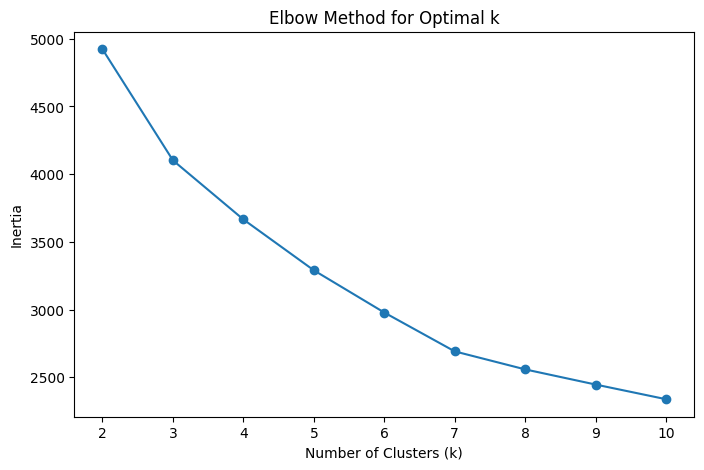

In [6]:
from sklearn.cluster import KMeans

inertia_values = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_values, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

### X_scaled Version-1
Initial clustering (k=5) revealed Cluster 2 mixed extremely high and low-wage occupations, driven by raw employment size dominating the distance calculation.
(Cluster 2 mixing Software Developers with Fast Food Workers purely due to raw employment size).

In [7]:
kmeans_final = KMeans(n_clusters=5, random_state=42, n_init=10)
features["cluster"] = kmeans_final.fit_predict(X_scaled)

print(features["cluster"].value_counts())

cluster
0    234
3    211
4    183
1    107
2     20
Name: count, dtype: int64


In [8]:
for cluster_num in sorted(features["cluster"].unique()):
    print(f"\n=== Cluster {cluster_num} ===")
    sample = features[features["cluster"] == cluster_num][["occupation_title","median_wage","employment"]]
    print(sample.head(10))


=== Cluster 0 ===
                         occupation_title  median_wage  employment
33                  Funeral Home Managers      78790.0     13910.0
38      Insurance Appraisers, Auto Damage      78240.0     11560.0
55                        Credit Analysts      83510.0     64390.0
62                          Tax Preparers      54920.0     76480.0
67   Computer Network Support Specialists      76220.0    146190.0
73                   Computer Programmers     100390.0     92230.0
76                         Web Developers      92650.0     70190.0
77    Web and Digital Interface Designers     104000.0    113330.0
87    Cartographers and Photogrammetrists      81390.0     14260.0
107      Architectural and Civil Drafters      66150.0    103700.0

=== Cluster 1 ===
                                     occupation_title  median_wage  employment
0                                    Chief Executives     213990.0    204350.0
9           Computer and Information Systems Managers     175140.0 

### X_v2_scaled Version-2
 Applied a log transform to employment before re-clustering.

In [9]:
import numpy as np

features["employment_log"] = np.log1p(features["employment"])

feature_columns_v2 = ["Active Learning", "Active Listening", "Critical Thinking", "Learning Strategies",
                       "Mathematics", "Monitoring", "Reading Comprehension", "Science", "Speaking", "Writing",
                       "employment_log", "median_wage"]

X_v2 = features[feature_columns_v2]
X_v2_scaled = scaler.fit_transform(X_v2)

print(X_v2_scaled[:5])

[[ 1.20290832  0.90853792  1.91864804  0.60884094  1.2836559   1.80001621
   1.19411549 -0.28087458  1.45320294  1.50137447  0.85139336  3.02911473]
 [ 0.96935584  0.90853792  0.86227788  0.40996944  0.20079534  1.80001621
   0.98521618 -0.41810824  0.96582389  0.558989    2.52338065  0.68130193]
 [ 0.53818202  1.15663466  0.86227788  0.40996944  0.64769017  0.54232368
   0.55000928 -0.41810824  1.19976584  0.93898314 -0.47437086  1.2863703 ]
 [ 1.43646081  1.15663466  0.86227788  0.82428507  0.85394933  1.49817001
   0.77631687 -0.13220479  0.96582389  0.17899486  1.23954089  2.0051195 ]
 [ 1.20290832  0.90853792  0.86227788  0.60884094  0.85394933  1.49817001
   0.77631687 -0.28087458  0.96582389  0.74138619  1.52044773  1.60333154]]


In [10]:
features.head()

,soc_code,Active Learning,Active Listening,Critical Thinking,Learning Strategies,Mathematics,Monitoring,Reading Comprehension,Science,Speaking,Writing,occupation_title,employment,median_wage,cluster,employment_log
0,11-1011,3.75,4.00,4.38,3.12,3.25,4.00,4.12,1.62,4.25,4.12,Chief Executives,204350.0,213990.0,1,12.227594
1,11-1021,3.62,4.00,3.88,3.00,2.62,4.00,4.00,1.50,4.00,3.50,General and Operations Managers,3503020.0,105770.0,2,15.069136
2,11-2011,3.38,4.12,3.88,3.00,2.88,3.50,3.75,1.50,4.12,3.75,Advertising and Promotions Managers,21470.0,133660.0,3,9.974458
3,11-2021,3.88,4.12,3.88,3.25,3.00,3.88,3.88,1.75,4.00,3.25,Marketing Managers,395240.0,166790.0,3,12.887251
4,11-2022,3.75,4.00,3.88,3.12,3.00,3.88,3.88,1.62,4.00,3.62,Sales Managers,637080.0,148270.0,3,13.364652


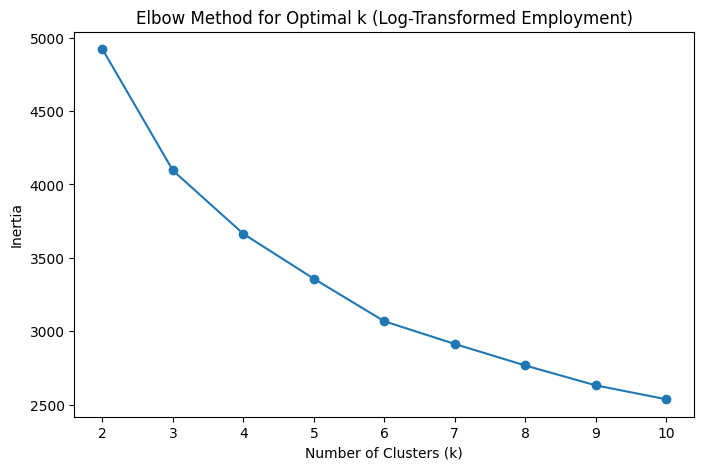

In [11]:
inertia_values_v2 = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_v2_scaled)
    inertia_values_v2.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_values_v2, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k (Log-Transformed Employment)")
plt.show()

In [12]:
kmeans_v2 = KMeans(n_clusters=5, random_state=42, n_init=10)
features["cluster_v2"] = kmeans_v2.fit_predict(X_v2_scaled)

print(features["cluster_v2"].value_counts())

cluster_v2
0    248
1    225
3    157
4    106
2     19
Name: count, dtype: int64


In [13]:
for cluster_num in sorted(features["cluster_v2"].unique()):
    print(f"\n=== Cluster {cluster_num} ===")
    sample = features[features["cluster_v2"] == cluster_num][["occupation_title", "median_wage", "employment"]]
    print(sample.head(10))


=== Cluster 0 ===
                                      occupation_title  median_wage  \
42                              Farm Labor Contractors      58460.0   
243                                      Craft Artists      46080.0   
244  Fine Artists, Including Painters, Sculptors, a...      55490.0   
251         Merchandise Displayers and Window Trimmers      39390.0   
270        Court Reporters and Simultaneous Captioners      72420.0   
341                                          Orderlies      38290.0   
347                                 Massage Therapists      58450.0   
363                                           Bailiffs      56600.0   
367                        Parking Enforcement Workers      46730.0   
374                       Crossing Guards and Flaggers      38100.0   

     employment  
42        310.0  
243      4580.0  
244     11220.0  
251    165220.0  
270     12870.0  
341     52440.0  
347     98790.0  
363     17310.0  
367      9050.0  
374     94360.0  



In [14]:
cluster_names = {
    0: "Niche/Specialized Lower-Mid Wage Roles",
    1: "Mid-Wage Financial & Analytical Specialists",
    2: "Elite High-Wage Executives & Medical Specialists",
    3: "Business & Operations Management",
    4: "Quantitative/Technical Specialists & Managers",
}

features["cluster_name"] = features["cluster_v2"].map(cluster_names)

features[["occupation_title", "soc_code", "median_wage", "employment", "cluster_v2", "cluster_name"]].to_csv(
    "../data/processed/occupation_clusters.csv", index=False
)
print("Saved.")

Saved.


In [15]:
from sklearn.linear_model import LinearRegression

def forecast_occupation(occupation_data: pd.DataFrame, target_years: list) -> dict:
    occupation_data = occupation_data.dropna(subset=["employment"])

    if len(occupation_data) < 2:
        return {year: None for year in target_years}

    X_years = occupation_data["year"].values.reshape(-1, 1)
    y_employment = occupation_data["employment"].values

    model = LinearRegression()
    model.fit(X_years, y_employment)

    predictions = {}
    for year in target_years:
        pred = model.predict([[year]])[0]
        predictions[year] = pred

    return predictions

In [16]:
test_occupation = oews_full[oews_full["occupation_title"] == "Data Scientists"]
result = forecast_occupation(test_occupation, [2030, 2035])
print(result)

{2030: np.float64(461551.0), 2035: np.float64(654916.0)}


In [17]:
forecast_results = []

for soc_code in features["soc_code"].unique():
    occ_data = oews_full[oews_full["soc_code"] == soc_code]
    if len(occ_data) < 2:
        continue

    occ_title = occ_data["occupation_title"].iloc[0]
    preds = forecast_occupation(occ_data, [2030, 2035])

    forecast_results.append({
        "soc_code": soc_code,
        "occupation_title": occ_title,
        "employment_2025": occ_data[occ_data["year"] == 2025]["employment"].values[0] if 2025 in occ_data["year"].values else None,
        "forecast_2030": preds[2030],
        "forecast_2035": preds[2035],
    })

forecast_df = pd.DataFrame(forecast_results)
print(forecast_df.shape)
forecast_df.head(10)

(755, 5)


,soc_code,occupation_title,employment_2025,forecast_2030,forecast_2035
0,11-1011,Chief Executives,204350.0,1.899927e+05,1.802941e+05
1,11-1021,General and Operations Managers,3503020.0,4.505220e+06,5.369624e+06
2,11-2011,Advertising and Promotions Managers,21470.0,1.500000e+04,1.036909e+04
3,11-2021,Marketing Managers,395240.0,5.016136e+05,6.093068e+05
4,11-2022,Sales Managers,637080.0,7.613573e+05,9.111236e+05
5,11-2032,Public Relations Managers,74850.0,9.880600e+04,1.196960e+05
6,11-2033,Fundraising Managers,38810.0,6.073800e+04,8.169800e+04
7,11-3012,Administrative Services Managers,263960.0,3.117370e+05,3.598620e+05
8,11-3013,Facilities Managers,156180.0,2.231830e+05,2.901880e+05
9,11-3021,Computer and Information Systems Managers,670570.0,8.277873e+05,1.002150e+06


In [22]:
bls_projections_raw = pd.read_excel(
    "../data/raw/bls_projections/bls_official_projections_2024_2034.xlsx",
    sheet_name="Table 1.2",
    header=1
)
print(bls_projections_raw.columns.tolist())
print(bls_projections_raw.head())

['2025 National Employment Matrix title', '2025 National Employment Matrix code', 'Occupation type', 'Employment, 2025', 'Employment, 2035', 'Employment distribution, percent, 2025', 'Employment distribution, percent, 2035', 'Employment change, numeric, 2025–35', 'Employment change, percent, 2025–35', 'Percent self-employed, 2025', 'Occupational openings, 2025–35 annual average', 'Median annual wage, dollars, 2025', 'Typical education needed for entry', 'Work experience in a related occupation', 'Typical on-the-job training needed to attain competency in the occupation', 'Related Occupational Outlook Handbook (OOH) content', 'Related Occupational Outlook Handbook (OOH) content.1']
   2025 National Employment Matrix title 2025 National Employment Matrix code  \
0                 Total, all occupations                              00-0000   
1                 Management occupations                              11-0000   
2                         Top executives                           

In [27]:
bls_official = bls_projections_raw[bls_projections_raw["Occupation type"] == "Line item"].copy()

bls_official_clean = bls_official[[
    "2025 National Employment Matrix code",
    "2025 National Employment Matrix title",
    "Employment, 2025",
    "Employment, 2035",
    "Employment change, percent, 2025–35",
    "Median annual wage, dollars, 2025"
]].copy()

bls_official_clean = bls_official_clean.rename(columns={
    "2025 National Employment Matrix code": "soc_code",
    "2025 National Employment Matrix title": "occupation_title_bls",
    "Employment, 2025": "bls_employment_2025",
    "Employment, 2035": "bls_employment_2035",
    "Employment change, percent, 2025–35": "bls_pct_change",
    "Median annual wage, dollars, 2025": "bls_median_wage_2025"
})

print(bls_official_clean.shape)
bls_official_clean.head()

(831, 6)


,soc_code,occupation_title_bls,bls_employment_2025,bls_employment_2035,bls_pct_change,bls_median_wage_2025
3,11-1011,Chief executives,291.6,300.9,3.2,213990
4,11-1021,General and operations managers,3599.0,3780.3,5.0,105770
6,11-2011,Advertising and promotions managers,33.2,31.9,-3.7,133660
8,11-2021,Marketing managers,421.6,450.8,6.9,166790
9,11-2022,Sales managers,650.1,679.1,4.5,148270


In [32]:
comparison = forecast_df.merge(bls_official_clean, on="soc_code", how="inner")

comparison["your_pct_change_2035"] = ((comparison["forecast_2035"] - comparison["employment_2025"]) / comparison["employment_2025"]) * 100

comparison_final = comparison[[
    "soc_code", "occupation_title", "employment_2025", "forecast_2035",
    "your_pct_change_2035", "bls_employment_2035", "bls_pct_change"
]].copy()

print(comparison_final.shape)
comparison_final.head(10)

(755, 7)


,soc_code,occupation_title,employment_2025,forecast_2035,your_pct_change_2035,bls_employment_2035,bls_pct_change
0,11-1011,Chief Executives,204350.0,1.802941e+05,-11.771915,300.9,3.2
1,11-1021,General and Operations Managers,3503020.0,5.369624e+06,53.285568,3780.3,5.0
2,11-2011,Advertising and Promotions Managers,21470.0,1.036909e+04,-51.704281,31.9,-3.7
3,11-2021,Marketing Managers,395240.0,6.093068e+05,54.161223,450.8,6.9
4,11-2022,Sales Managers,637080.0,9.111236e+05,43.015577,679.1,4.5
5,11-2032,Public Relations Managers,74850.0,1.196960e+05,59.914496,85.4,5.7
6,11-2033,Fundraising Managers,38810.0,8.169800e+04,110.507601,51.4,5.4
7,11-3012,Administrative Services Managers,263960.0,3.598620e+05,36.332020,293.3,5.2
8,11-3013,Facilities Managers,156180.0,2.901880e+05,85.803560,173.5,4.6
9,11-3021,Computer and Information Systems Managers,670570.0,1.002150e+06,49.447485,793.9,15.8


Average absolute difference between our model and BLS: 34.31471249900867


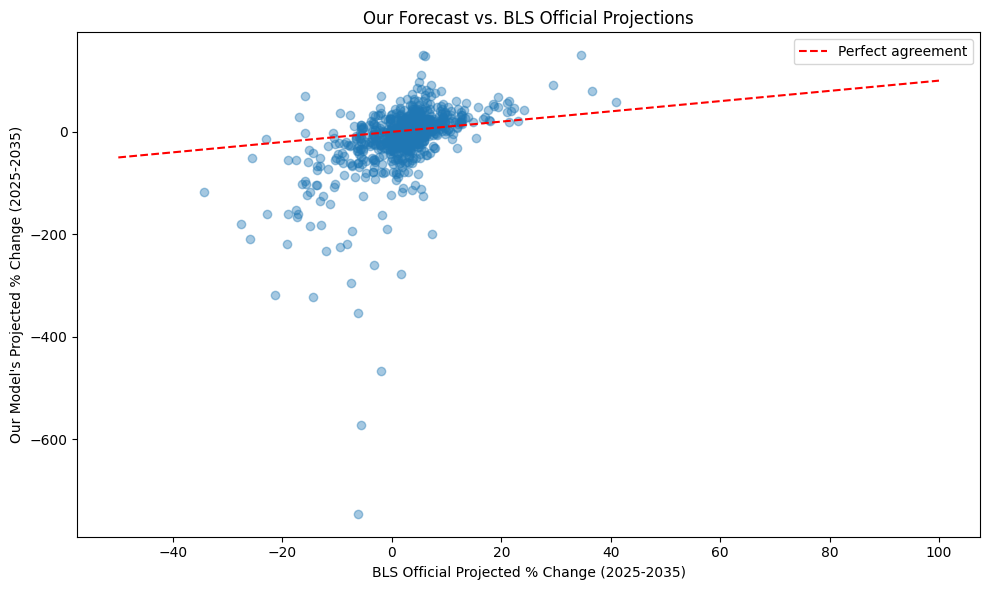

In [29]:
comparison_final["forecast_error"] = comparison_final["your_pct_change_2035"] - comparison_final["bls_pct_change"]

print("Average absolute difference between our model and BLS:", comparison_final["forecast_error"].abs().mean())

plt.figure(figsize=(10, 6))
plt.scatter(comparison_final["bls_pct_change"], comparison_final["your_pct_change_2035"], alpha=0.4)
plt.plot([-50, 100], [-50, 100], color="red", linestyle="--", label="Perfect agreement")
plt.xlabel("BLS Official Projected % Change (2025-2035)")
plt.ylabel("Our Model's Projected % Change (2025-2035)")
plt.title("Our Forecast vs. BLS Official Projections")
plt.legend()
plt.tight_layout()
plt.show()

In [30]:
print("Average absolute difference between our model and BLS:", comparison_final["forecast_error"].abs().mean())

Average absolute difference between our model and BLS: 34.31471249900867


In [33]:
comparison_final.to_csv("../data/processed/forecast_vs_bls_comparison.csv", index=False)
forecast_df.to_csv("../data/processed/employment_forecast_2030_2035.csv", index=False)
print("Saved.")

Saved.


In [35]:
import shutil
shutil.copy("../data/processed/forecast_vs_bls_comparison.csv", "../data/curated/forecast_vs_bls_comparison.csv")
print("Copied.")

Copied.
